<a href="https://colab.research.google.com/github/Mz72100/Machine-learning-toturial/blob/main/Hyper_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Fraudulent Transaction Detection in Financial Systems.**

# **Part 1: Loading Library Files and Dataset**

In [ ]:
import pandas as pd
import numpy as np

# Load the training data
train_transaction = pd.read_csv('train_transaction.csv')
train_identity = pd.read_csv('train_identity.csv')

# Load the test data
test_transaction = pd.read_csv('test_transaction.csv')
test_identity = pd.read_csv('test_identity.csv')

print(f"Train Transaction shape: {train_transaction.shape}")
print(f"Train Identity shape: {train_identity.shape}")

Train Transaction shape: (137226, 394)
Train Identity shape: (144233, 41)


## **Merging Dataset**

In [ ]:
# Merge Train data
train = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')

# Merge Test data
test = pd.merge(test_transaction, test_identity, on='TransactionID', how='left')

print(f"Final Train shape: {train.shape}")
print(f"Final Test shape: {test.shape}")

Final Train shape: (137226, 434)
Final Test shape: (141450, 433)


In [ ]:
# Check target distribution
fraud_pct = train['isFraud'].value_counts(normalize=True) * 100
print(f"Target distribution:\n{fraud_pct}")

# Preview the first few rows
train.head()

Target distribution:
isFraud
0    97.413755
1     2.586245
Name: proportion, dtype: float64


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


# **Part 2: Exploratory Data Analysis**

## **Exploring Basic Dataset**

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137226 entries, 0 to 137225
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), object(31)
memory usage: 454.4+ MB


In [ ]:
train.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


## **Checking Duplicate Rows**

In [ ]:
# Check for exact duplicate rows across the entire merged dataframe
duplicates = train.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Check specifically for duplicate TransactionIDs (should be 0)
id_duplicates = train['TransactionID'].duplicated().sum()
print(f"Number of duplicate TransactionIDs: {id_duplicates}")

Number of duplicate rows: 0
Number of duplicate TransactionIDs: 0


## **Checking Missing Values**

In [ ]:
# Calculate missing values
null_counts = train.isnull().sum()
null_percent = (null_counts / len(train)) * 100

# Create a summary table
missing_data = pd.DataFrame({
    'Total Missing': null_counts,
    'Percentage (%)': null_percent
}).sort_values(by='Percentage (%)', ascending=False)

# Filter for columns that actually have missing values
missing_data_filtered = missing_data[missing_data['Total Missing'] > 0]

print(f"Total columns with missing values: {len(missing_data_filtered)}")
print("\nTop 20 columns with highest missing percentage:")
print(missing_data_filtered.head(20))

Total columns with missing values: 413

Top 20 columns with highest missing percentage:
       Total Missing  Percentage (%)
id_24         135171       98.502470
id_25         135033       98.401906
id_21         135025       98.396077
id_07         135022       98.393890
id_08         135022       98.393890
id_26         135022       98.393890
id_22         135021       98.393162
id_23         135021       98.393162
id_27         135021       98.393162
D7            128233       93.446577
dist2         125259       91.279349
D13           122912       89.569032
D12           121316       88.405987
D14           120871       88.081705
id_18         119119       86.804979
D6            118188       86.126536
M7            115745       84.346261
M8            115745       84.346261
M9            115745       84.346261
id_03         111701       81.399298


## **Visualizing the distribution of missing values**

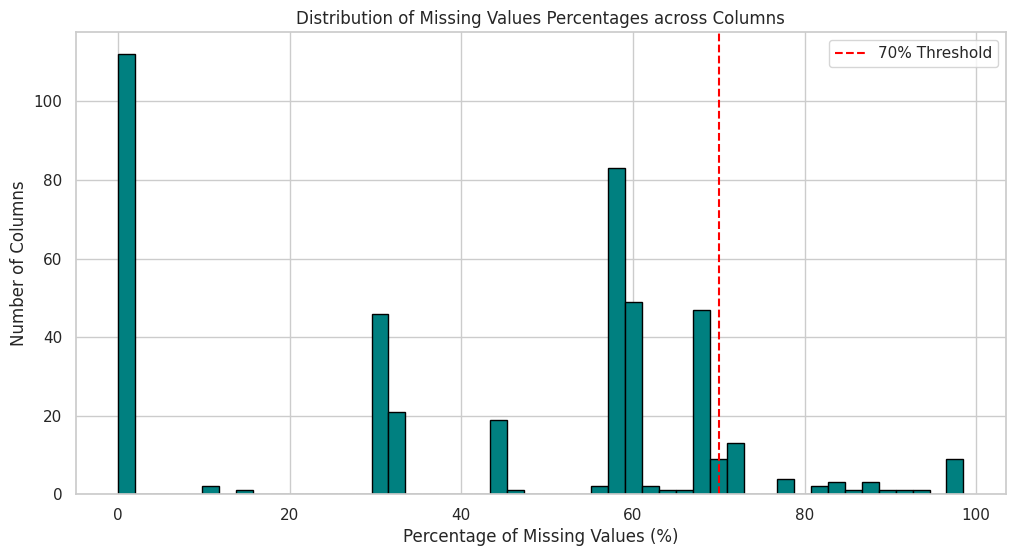

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizing the distribution of missing values across all columns
plt.figure(figsize=(12, 6))
plt.hist(null_percent, bins=50, color='teal', edgecolor='black')
plt.axvline(x=70, color='red', linestyle='--', label='70% Threshold')
plt.title('Distribution of Missing Values Percentages across Columns')
plt.xlabel('Percentage of Missing Values (%)')
plt.ylabel('Number of Columns')
plt.legend()
plt.show()

## **Handling Missing Values**

In [ ]:
# Identify columns to drop from the missing_data analysis done on Train
threshold = 80
cols_to_drop = missing_data[missing_data['Percentage (%)'] > threshold].index.tolist()

print(f"Attempting to drop {len(cols_to_drop)} columns...")

# Use errors='ignore' so if a column isn't in 'test', it just skips it
train_reduced = train.drop(columns=cols_to_drop, errors='ignore')
test_reduced = test.drop(columns=cols_to_drop, errors='ignore')

print(f"Final Train shape: {train_reduced.shape}")
print(f"Final Test shape: {test_reduced.shape}")

Attempting to drop 21 columns...
Final Train shape: (137226, 413)
Final Test shape: (141450, 424)


## **Target Variable distribution**

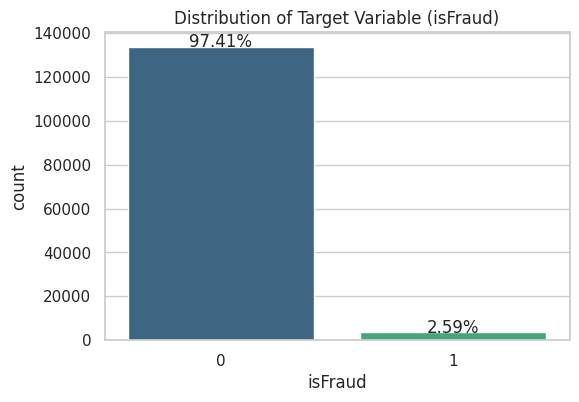

In [ ]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='isFraud', data=train, palette='viridis')
plt.title('Distribution of Target Variable (isFraud)')

# Adding percentages on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 3,
            '{:1.2f}%'.format(height/len(train)*100), ha="center")
plt.show()

## **Distribution of Transaction Amount and by Fraud Status**

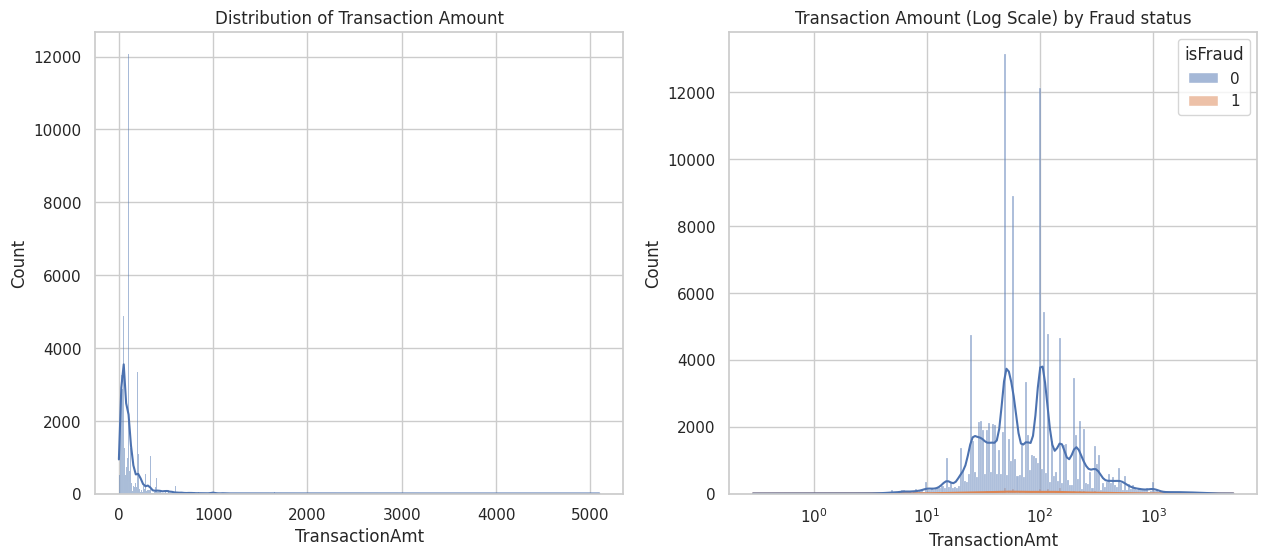

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Distribution of Transaction Amount
sns.histplot(train['TransactionAmt'], ax=ax1, kde=True)
ax1.set_title('Distribution of Transaction Amount')

# Log Distribution of Transaction Amount by Fraud status
sns.histplot(data=train, x='TransactionAmt', hue='isFraud', log_scale=True, kde=True, ax=ax2)
ax2.set_title('Transaction Amount (Log Scale) by Fraud status')

plt.show()

## **Percentage of Fraudlent Transactions**

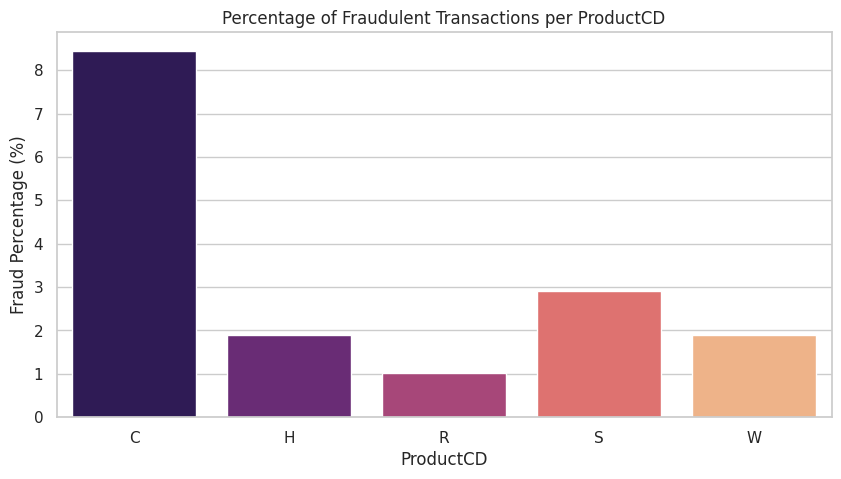

In [ ]:
# Analyzing ProductCD vs Fraud
tmp = pd.crosstab(train['ProductCD'], train['isFraud'], normalize='index') * 100
tmp = tmp.reset_index()
tmp.rename(columns={0:'No Fraud', 1:'Fraud'}, inplace=True)

plt.figure(figsize=(10, 5))
sns.barplot(x='ProductCD', y='Fraud', data=tmp, palette='magma')
plt.title('Percentage of Fraudulent Transactions per ProductCD')
plt.ylabel('Fraud Percentage (%)')
plt.show()

## **Transaction over Time**

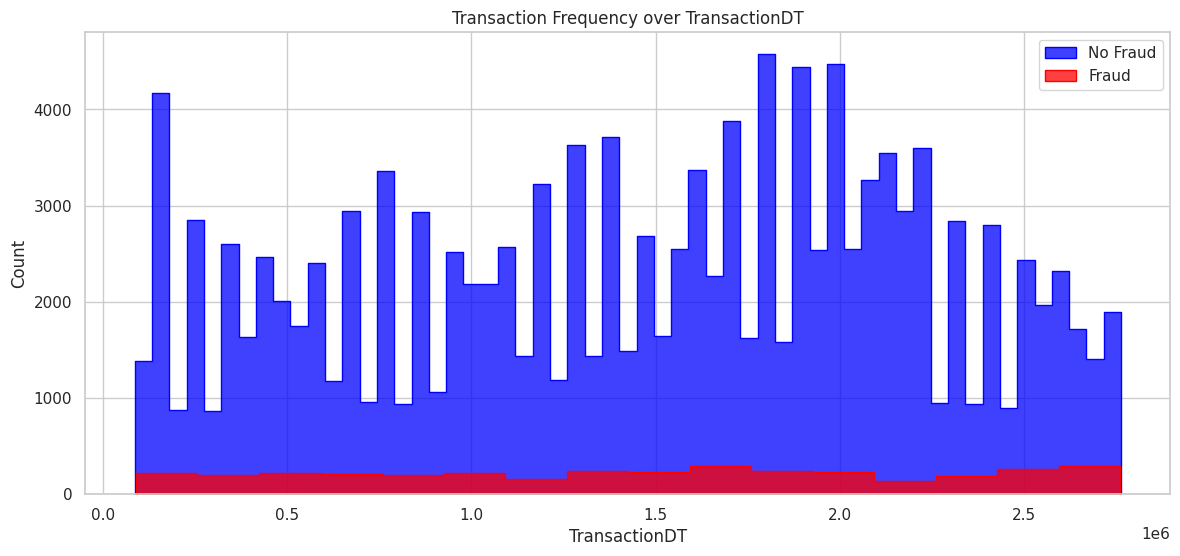

In [ ]:
# Simple plot of transactions over the 'time' variable
plt.figure(figsize=(14, 6))
sns.histplot(train[train['isFraud']==0]['TransactionDT'], label='No Fraud', color='blue', element="step")
sns.histplot(train[train['isFraud']==1]['TransactionDT'], label='Fraud', color='red', element="step")
plt.legend()
plt.title('Transaction Frequency over TransactionDT')
plt.show()

# **Part 3: Preprocessing**

In [ ]:
from sklearn.preprocessing import LabelEncoder

# 1. Redefine categorical columns based on what's actually in the reduced dataframe
current_categorical_cols = train_reduced.select_dtypes(include=['object']).columns.tolist()

# 2. Safely encode only the columns that exist
train_encoded = train_reduced.copy()
for col in current_categorical_cols:
    if col in train_encoded.columns:
        le = LabelEncoder()
        train_encoded[col] = le.fit_transform(train_encoded[col].astype(str))

# 3. Define X and y by checking available columns
# We drop 'isFraud' and 'TransactionID', plus any other non-feature columns
cols_to_exclude = ['isFraud', 'TransactionID']
feature_cols = [c for c in train_encoded.columns if c not in cols_to_exclude]

X = train_encoded[feature_cols]
y = train_encoded['isFraud']

print(f"Data prepared. Total features: {len(feature_cols)}")
print(f"Target distribution: {y.value_counts(normalize=True)[1]:.2%} Fraud")

Data prepared. Total features: 411
Target distribution: 2.59% Fraud


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
import time
import numpy as np

# Using 3 folds for faster execution in Colab; 5 is standard for research
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

def evaluate_model(model, name, X_data, y_data):
    auprc_scores = []
    print(f"--- Training {name} ---")
    start_time = time.time()

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_data, y_data)):
        X_train, X_val = X_data.iloc[train_idx], X_data.iloc[val_idx]
        y_train, y_val = y_data.iloc[train_idx], y_data.iloc[val_idx]

        # Fit model
        model.fit(X_train, y_train)

        # Predict probabilities for the Fraud class (1)
        preds = model.predict_proba(X_val)[:, 1]

        # Calculate AUPRC
        score = average_precision_score(y_val, preds)
        auprc_scores.append(score)
        print(f"Fold {fold+1} AUPRC: {score:.4f}")

    avg_score = np.mean(auprc_scores)
    runtime = time.time() - start_time
    print(f"Finished {name}. Avg AUPRC: {avg_score:.4f} | Time: {runtime:.2f}s\n")
    return avg_score, runtime

In [ ]:
from sklearn.model_selection import train_test_split

# Split data 80/20
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training samples: {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")

Training samples: 109780
Validation samples: 27446


# **Part 4: Training & Evaluating Models**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
import time

# Initialize models
models = {
    "XGBoost": XGBClassifier(n_estimators=300, scale_pos_weight=25, tree_method='hist', random_state=42),
    "LightGBM": LGBMClassifier(n_estimators=300, is_unbalance=True, device='cpu', random_state=42),
    "CatBoost": CatBoostClassifier(iterations=300, auto_class_weights='Balanced', verbose=0, task_type="CPU", random_state=42)
}

performance_stats = []
predictions = {}
probabilities = {}

for name, model in models.items():
    # Measure Train Time
    start_train = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_train

    # Measure Test Time
    start_test = time.time()
    y_pred = model.predict(X_val)
    test_time = time.time() - start_test

    y_proba = model.predict_proba(X_val)[:, 1]

    # Store results
    predictions[name] = y_pred
    probabilities[name] = y_proba

    performance_stats.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1-Score": f1_score(y_val, y_pred),
        "AUC-ROC": roc_auc_score(y_val, y_proba),
        "Train Time (s)": train_time,
        "Test Time (s)": test_time
    })

# Display Performance Table
perf_df = pd.DataFrame(performance_stats)
print(perf_df.to_string(index=False))

[LightGBM] [Info] Number of positive: 2839, number of negative: 106941
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.239868 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 31331
[LightGBM] [Info] Number of data points in the train set: 109780, number of used features: 409
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.025861 -> initscore=-3.628825
[LightGBM] [Info] Start training from score -3.628825
   Model  Accuracy  Precision   Recall  F1-Score  AUC-ROC  Train Time (s)  Test Time (s)
 XGBoost  0.988049   0.809061 0.704225  0.753012 0.942268       38.736121       0.467245
LightGBM  0.968848   0.441767 0.774648  0.562660 0.943341       42.168714       0.990861
CatBoost  0.963638   0.396552 0.777465  0.525214 0.929491       64.061050       0.085073


## **Evaluating Models**


--- Classification Report: XGBoost ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     26736
           1       0.81      0.70      0.75       710

    accuracy                           0.99     27446
   macro avg       0.90      0.85      0.87     27446
weighted avg       0.99      0.99      0.99     27446


--- Classification Report: LightGBM ---
              precision    recall  f1-score   support

           0       0.99      0.97      0.98     26736
           1       0.44      0.77      0.56       710

    accuracy                           0.97     27446
   macro avg       0.72      0.87      0.77     27446
weighted avg       0.98      0.97      0.97     27446


--- Classification Report: CatBoost ---
              precision    recall  f1-score   support

           0       0.99      0.97      0.98     26736
           1       0.40      0.78      0.53       710

    accuracy                           0.96     27446
   mac

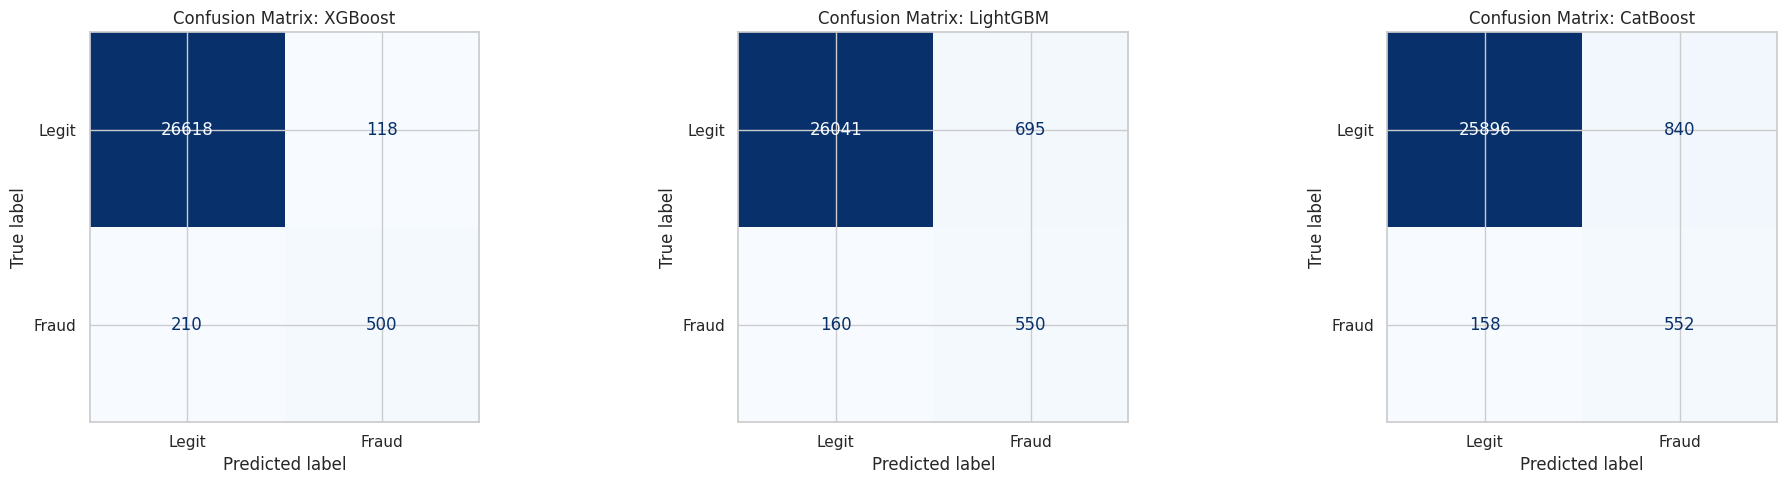

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for i, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legit', 'Fraud'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f"Confusion Matrix: {name}")

    print(f"\n--- Classification Report: {name} ---")
    print(classification_report(y_val, y_pred))

plt.tight_layout()
plt.show()

## **ROC Curve**

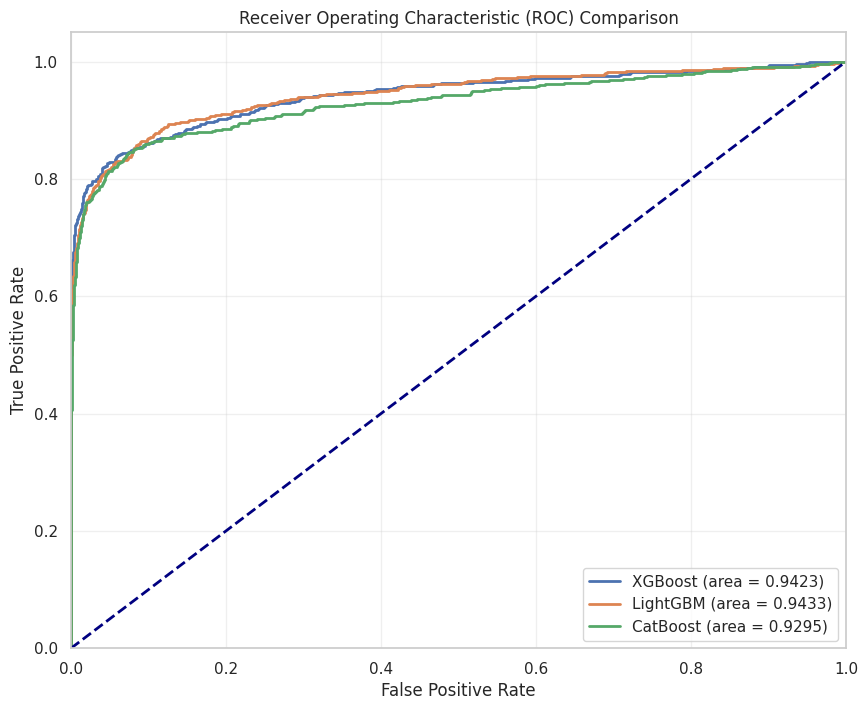

In [ ]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

for name, y_proba in probabilities.items():
    fpr, tpr, _ = roc_curve(y_val, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (area = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Comparison')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# **Part 5: Hyperparameter Optimization with HalvingGrid Search**

In [ ]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
import time

# Dictionary to store the best models and their stats
best_tuned_models = {}
tuning_results = []

def run_fast_tuning(name, estimator, param_grid):
    print(f"--- Starting Fast Tuning for {name} ---")
    start_time = time.time()

    # Using HalvingGridSearchCV for speed
    # factor=3 means we keep the top 1/3 performers in each round
    hgs = HalvingGridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        factor=3,
        resource='n_samples',
        max_resources='auto',
        scoring='average_precision', # Focusing on AUPRC for fraud
        cv=3,
        n_jobs=-1,
        random_state=42
    )

    hgs.fit(X_train, y_train)
    duration = time.time() - start_time

    print(f"{name} Tuning Complete in {duration:.2f}s")
    print(f"Best Params: {hgs.best_params_}\n")

    return hgs.best_estimator_, hgs.best_params_, duration

In [ ]:
# XGBoost Grid
xgb_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100] # Keep low for tuning, increase for final fit
}

# LightGBM Grid
lgbm_grid = {
    'num_leaves': [31, 64],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100]
}

# CatBoost Grid
cat_grid = {
    'depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'iterations': [100]
}

# Define the models (using CPU as per your previous setting)
models_to_tune = {
    "XGBoost": (XGBClassifier(scale_pos_weight=25, tree_method='hist', random_state=42), xgb_grid),
    "LightGBM": (LGBMClassifier(is_unbalance=True, device='cpu', random_state=42, verbose=-1), lgbm_grid),
    "CatBoost": (CatBoostClassifier(auto_class_weights='Balanced', verbose=0, task_type="CPU", random_state=42), cat_grid)
}

## **Evaluting After Optimization**

In [ ]:
final_stats = []

for name, (model, grid) in models_to_tune.items():
    # 1. Run the fast tuning
    best_model, best_params, tune_time = run_fast_tuning(name, model, grid)

    # 2. Final Prediction using the best version
    y_pred = best_model.predict(X_val)
    y_proba = best_model.predict_proba(X_val)[:, 1]

    # 3. Collect Metrics
    final_stats.append({
        "Model": name,
        "AUPRC": average_precision_score(y_val, y_proba),
        "F1-Score": f1_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Tuning Time (s)": tune_time
    })

# Display final comparison table
tuning_df = pd.DataFrame(final_stats)
print(tuning_df.to_string(index=False))

--- Starting Fast Tuning for XGBoost ---
XGBoost Tuning Complete in 250.35s
Best Params: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 100}

--- Starting Fast Tuning for LightGBM ---
LightGBM Tuning Complete in 265.08s
Best Params: {'learning_rate': 0.1, 'n_estimators': 100, 'num_leaves': 64}

--- Starting Fast Tuning for CatBoost ---
CatBoost Tuning Complete in 216.18s
Best Params: {'depth': 6, 'iterations': 100, 'learning_rate': 0.1}

   Model    AUPRC  F1-Score   Recall  Precision  Tuning Time (s)
 XGBoost 0.722848  0.575888 0.753521   0.466028       250.347302
LightGBM 0.717908  0.502279 0.776056   0.371294       265.076670
CatBoost 0.530388  0.249831 0.778873   0.148776       216.180841


# **Part 6: K-Fold Cross Validation**

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd

# 1. Initialize the Stratified K-Fold
# 5 folds is the industry standard for research
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Define the metrics we want to track across all folds
scoring_metrics = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'auprc': 'average_precision'
}

cv_results_list = []

# 3. Run CV for each tuned model
for name, (model, grid) in models_to_tune.items():
    print(f"--- Running 5-Fold CV for {name} ---")

    # We use cross_validate to get multiple metrics at once
    cv_results = cross_validate(
        model, X, y,
        cv=skf,
        scoring=scoring_metrics,
        n_jobs=-1, # Use all CPU cores
        return_train_score=False
    )

    # Calculate means for the results
    cv_results_list.append({
        "Model": name,
        "CV_Accuracy": cv_results['test_accuracy'].mean(),
        "CV_Precision": cv_results['test_precision'].mean(),
        "CV_Recall": cv_results['test_recall'].mean(),
        "CV_F1": cv_results['test_f1'].mean(),
        "CV_AUC_ROC": cv_results['test_roc_auc'].mean(),
        "CV_AUPRC": cv_results['test_auprc'].mean()
    })

# Display the Final CV Results
cv_df = pd.DataFrame(cv_results_list)
print(cv_df.to_string(index=False))

--- Running 5-Fold CV for XGBoost ---
--- Running 5-Fold CV for LightGBM ---
--- Running 5-Fold CV for CatBoost ---
   Model  CV_Accuracy  CV_Precision  CV_Recall    CV_F1  CV_AUC_ROC  CV_AUPRC
 XGBoost     0.971667      0.470095   0.739648 0.574593    0.943039  0.718978
LightGBM     0.927281      0.234690   0.801074 0.363014    0.935308  0.651239
CatBoost     0.971398      0.469041   0.784731 0.586798    0.948401  0.750567
